# Bayesian BLP on the Nevo (2000) Cereal Panel

This notebook applies `BayesianBLP` to the canonical aggregate-share demand dataset from Nevo's *"A Practitioner's Guide to Estimation of Random Coefficients Logit Models of Demand"*: 24 ready-to-eat cereal brands across 47 US cities × 2 quarters, with prices, two product characteristics (sugar content, mushy indicator), and Nevo's five Hausman-style instruments (`z6`..`z10`).

We will:

1. Load and clean the public Nevo panel.
2. Synthesize the outside-good rows (Nevo's data ships without one).
3. Fit `BayesianBLP` with `nutpie` on a tractable subset of cities.
4. Check posterior diagnostics ($\hat{R}$ and ESS).
5. Show the IV correction holds on real data.
6. Inspect own-price elasticities and run two counterfactuals (panel-wide and time-targeted).
7. Read the per-market taste profiles to see which consumer types each market relies on.

**Note on the data.** Nevo (2000) states that the Practitioner's Guide dataset is *simulated data calibrated to the cereal market*, not actual scanner data. The real empirical results are in Nevo (2001, Econometrica). We use the simulated panel because it is the standard teaching example.


> **Before you read this notebook.** The methodology, prior structure, IV decomposition, hierarchical pooling, and counterfactual mechanics are introduced in [`bayesian_blp.ipynb`](bayesian_blp.ipynb) using a synthetic panel with known truth. This notebook assumes you have read that one. Here we apply the same model to the canonical empirical dataset and check that it reproduces the elasticity range published in the literature.


In [1]:
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pymc_marketing.customer_choice import BayesianBLP, taste_profiles

warnings.filterwarnings("ignore")
az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 4]
plt.rcParams["figure.dpi"] = 110
%config InlineBackend.figure_format = 'retina'

## 1. Load and inspect the Nevo panel

The CSV ships with European decimal formatting (`","` as the decimal separator), so we pass `decimal=","` to `pd.read_csv`. The raw layout is *inside-products only*: the outside good's share is implicit, equal to `1 - sum(inside_shares)` per market.


In [2]:
from pymc_marketing.paths import data_dir

raw = pd.read_csv(data_dir / "data_nevo.csv", decimal=",")

# Compose city x quarter -> (region, period). The original file has only
# year=88 and quarters 1, 2, so 47 cities x 2 quarters = 94 markets.
raw["period"] = raw["year"].astype(int) * 4 + raw["quarter"].astype(int)
raw["region"] = "c" + raw["city"].astype(str)
raw["market"] = raw["region"] + "_" + raw["period"].astype(str)
# Decode firm codes to readable names
FIRM_NAMES = {
    1: "Kelloggs",
    2: "GenMills",
    3: "Post",
    4: "Quaker",
    6: "Ralston",
}
raw["firm_name"] = raw["firm"].map(FIRM_NAMES)
raw["product"] = raw["firm_name"] + "_" + raw["brand"].astype(int).astype(str)

print(f"Rows: {len(raw)}")
print(f"Brands: {raw['firmbr'].nunique()}")
print(f"Cities: {raw['city'].nunique()}")
print(f"Quarters: {sorted(raw['quarter'].unique())}")
print(f"Markets (city × period): {raw.groupby(['city', 'period']).ngroups}")

market_share_sums = raw.groupby("market")["share"].sum()
print(
    f"\nInside-share sum per market: "
    f"mean={market_share_sums.mean():.3f}, "
    f"min={market_share_sums.min():.3f}, "
    f"max={market_share_sums.max():.3f}"
)
print(
    "→ Outside-good share averages "
    f"~{1 - market_share_sums.mean():.2f}; "
    "we synthesize one outside row per market below."
)
raw.head(4)

Rows: 2256
Brands: 24
Cities: 47
Quarters: [np.int64(1), np.int64(2)]
Markets (city × period): 94

Inside-share sum per market: mean=0.476, min=0.185, max=0.696
→ Outside-good share averages ~0.52; we synthesize one outside row per market below.


,id,firmbr,firm,brand,city,year,quarter,share,price,sugar,...,z16,z17,z18,z19,z20,period,region,market,firm_name,product
0,100401880,1004,1,4,1,88,1,0.0124,0.072,2.0,...,0.067,0.068,0.035,0.126,0.035,353,c1,c1_353,Kelloggs,Kelloggs_4
1,100601880,1006,1,6,1,88,1,0.0078,0.114,18.0,...,0.088,0.111,0.088,0.050,0.073,353,c1,c1_353,Kelloggs,Kelloggs_6
2,100701880,1007,1,7,1,88,1,0.0130,0.132,4.0,...,0.112,0.108,0.086,0.122,0.102,353,c1,c1_353,Kelloggs,Kelloggs_7
3,100901880,1009,1,9,1,88,1,0.0058,0.130,3.0,...,0.088,0.102,0.102,0.111,0.104,353,c1,c1_353,Kelloggs,Kelloggs_9


## 2. Build the `BayesianBLP` input

Three transformations:

1. **Subset.** The full 94-market × 24-brand panel produces a 2256-cell $\tilde{\xi}$ block whose joint geometry with $(\rho, \sigma_\xi)$ makes a CPU fit expensive (≈15 min). We subset to 8 cities × 2 quarters = 16 markets so the notebook fits in a few minutes. The methodology is identical at full scale.

2. **Rescale price.** Nevo's published price scale is "share of category dollar sales per serving" (≈0.05–0.22). The default `α ~ Normal(0, 2)` prior assumes a roughly unit-variance price scale, so on the raw Nevo scale the implied $\alpha \cdot p$ term in utility is too small and the posterior collapses to near-zero own-price elasticities. We multiply price by 100 (cents) so $|\alpha|$ naturally lands in the prior support.

3. **Synthesize outside rows.** One row per market and time, `share = 1 - Σ(inside)`, all characteristics, instruments, and price set to zero. This matches the convention used by the synthetic-data generator.


> **Caveat on the fabricated market size (`n=1,000`).** Nevo's dataset reports market *shares* but not market sizes (number of potential consumers). The log-share-ratio likelihood needs a per-cell variance scale, so we fill in a constant `n=1,000`. This is a methodological placeholder: posterior elasticity *magnitudes* scale with the assumed `n`, so absolute levels are not directly comparable with published Nevo results. Substitution patterns and elasticity *ratios* are unaffected.


In [3]:
N_CITIES_DEMO = 8
# Nevo's five Hausman-style instruments: prices of the same brand in
# other markets (z6..z10). The wider 20-instrument set is also available
# but adds little identifying variation for the diagonal-RC specification
# used here, so we match Nevo's original identification strategy.
INSTRUMENTS = [f"z{i}" for i in range(6, 11)]

# Subset to N_CITIES_DEMO cities x 2 quarters x 24 brands.
keep_cities = sorted(raw["city"].unique())[:N_CITIES_DEMO]
df_inside = raw[raw["city"].isin(keep_cities)].copy()
df_inside["price"] = df_inside["price"] * 100.0  # to cents

# Synthesize outside-good rows
market_share_sum = df_inside.groupby("market")["share"].sum()
outside_share = 1.0 - market_share_sum
market_meta = df_inside.drop_duplicates("market").set_index("market")[
    ["region", "period"]
]

outside = pd.DataFrame(
    {
        "market": outside_share.index,
        "product": "outside",
        "share": outside_share.values,
        "price": 0.0,
        "sugar": 0.0,
        "mushy": 0.0,
        **{c: 0.0 for c in INSTRUMENTS},
    }
)
outside["region"] = market_meta.reindex(outside["market"])["region"].values
outside["period"] = market_meta.reindex(outside["market"])["period"].values

# n_jt is required by the log-share-ratio likelihood as a per-cell
# variance scale, but Nevo's data does not include serving counts.
# We assign a *fabricated* constant n=1,000 so the likelihood is
# well-defined. Caveat: elasticity magnitudes scale with the implied
# variance, so absolute levels here should NOT be compared with
# published Nevo estimates. Patterns and ratios remain interpretable.
df_inside["n"] = 1000
outside["n"] = 1000

df = pd.concat([df_inside, outside], ignore_index=True, sort=False)

assert np.allclose(df.groupby("market")["share"].sum(), 1.0, atol=1e-6)  # noqa: S101
print(
    f"Final long-format frame: {len(df)} rows "
    f"(= {df['market'].nunique()} markets x {df['product'].nunique()} products)"
)
df[
    ["market", "region", "period", "product", "share", "price", "sugar", "mushy", "n"]
].head(6)

Final long-format frame: 400 rows (= 16 markets x 25 products)


,market,region,period,product,share,price,sugar,mushy,n
0,c1_353,c1,353,Kelloggs_4,0.0124,7.2,2.0,1.0,1000
1,c1_353,c1,353,Kelloggs_6,0.0078,11.4,18.0,1.0,1000
2,c1_353,c1,353,Kelloggs_7,0.0130,13.2,4.0,1.0,1000
3,c1_353,c1,353,Kelloggs_9,0.0058,13.0,3.0,0.0,1000
4,c1_353,c1,353,Kelloggs_11,0.0179,15.5,12.0,0.0,1000
5,c1_353,c1,353,Kelloggs_13,0.0266,13.7,14.0,0.0,1000


## 3. Construct and fit the model

We declare `region_col="region"` and `time_col="period"` so cities pool hierarchically on $\alpha_r$, and the period coordinate is exposed for time-targeted counterfactuals. The five instruments enable the conditional decomposition $\tilde{\xi} \mid \eta \sim N(\rho \sigma_\xi / \sigma_\eta \cdot \eta, \, \sigma_\xi \sqrt{1-\rho^2})$ that corrects for price endogeneity, the headline empirical concern in Nevo's paper.


In [4]:
from pymc_extras.prior import Prior

model = BayesianBLP(
    market_data=df,
    characteristics=["sugar", "mushy"],
    instruments=INSTRUMENTS,
    region_col="region",
    time_col="period",
    random_coef_on=["price", "sugar", "mushy"],
    n_mc_draws=200,
    model_config={
        "sigma_xi": Prior("HalfNormal", sigma=0.5),
        "sigma_xi_j": Prior("HalfNormal", sigma=0.25),
        "alpha": Prior("Normal", mu=0.0, sigma=3.0),  # slightly wider prior
    },
    random_seed=0,
    hierarchical_parameterisation="noncentered",
)
print(
    f"M={model._M} markets, J={model._J} inside products, "
    f"R={len(model._regions)} regions, T={model._T} periods, "
    f"K={model._K} characteristics, L={model._L} instruments"
)
print(
    f"Halton grid shape: {model._halton.shape}  (random_coef_on={model._random_coef_names})"
)

M=16 markets, J=24 inside products, R=8 regions, T=2 periods, K=2 characteristics, L=5 instruments
Halton grid shape: (200, 3)  (random_coef_on=['price', 'sugar', 'mushy'])


In [5]:
t0 = time.perf_counter()
model.fit(
    nuts_sampler="nutpie",
    draws=2000,
    tune=1000,
    chains=4,
    target_accept=0.95,
    progressbar=True,
    init="adapt_full",
    random_seed=0,
)
elapsed = time.perf_counter() - t0
n_div = int(model.idata.sample_stats["diverging"].sum())
print(f"\nFit took {elapsed:.0f}s ({elapsed / 60:.1f} min). Divergences: {n_div}")

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.08,127
,3000,0,0.08,63
,3000,0,0.08,63
,3000,0,0.07,63



Fit took 363s (6.1 min). Divergences: 0


## 4. Posterior diagnostics


In [6]:
# a) Headline summary on the parameters that drive predictions
az.summary(
    model.idata,
    var_names=[
        "alpha_pop",
        "beta_pop",
        "tau_alpha",
        "sigma_random",
        "rho_price_xi",
        "sigma_xi",
        "sigma_xi_j",
    ],
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_pop,-0.328,0.035,-0.395,-0.262,0.002,0.001,541.0,985.0,1.0
beta_pop[sugar],0.033,0.027,-0.019,0.084,0.001,0.001,837.0,1549.0,1.0
beta_pop[mushy],-0.234,0.311,-0.842,0.329,0.010,0.006,1071.0,1527.0,1.0
tau_alpha,0.070,0.029,0.029,0.124,0.001,0.001,745.0,1212.0,1.0
sigma_random[price],0.150,0.028,0.095,0.199,0.001,0.000,1261.0,1748.0,1.0
sigma_random[sugar],0.034,0.025,0.000,0.078,0.000,0.000,2751.0,2280.0,1.0
sigma_random[mushy],0.291,0.219,0.000,0.687,0.003,0.002,3421.0,2478.0,1.0
rho_price_xi,0.330,0.130,0.090,0.572,0.003,0.002,1742.0,2498.0,1.0
sigma_xi,0.745,0.051,0.653,0.840,0.001,0.001,1906.0,2652.0,1.0
sigma_xi_j,0.726,0.094,0.564,0.909,0.002,0.002,1564.0,2472.0,1.0


**Read this table for two things:**

- $\hat{R}$ close to 1 (≤ 1.02 ideal). Values 1.05–1.20 indicate chains that haven't fully mixed. This fit (4 chains × 2000 draws) should sit at ≈ 1.00 throughout.
- `ess_bulk` should be ≥ 100 for parameters you want to report. Note the wide HDI on `beta_pop[mushy]`: with characteristics that are constant per brand across markets (sugar and mushy never vary within a brand), the characteristic coefficients are nearly collinear with the brand fixed effects $\xi_j$, so `beta_pop` is identified mostly through the shrinkage prior on $\sigma_{\xi_j}$. The brand fixed effects absorb the same variation — this is the Bayesian analogue of the brand-dummy identification problem Nevo (2000) handles with a minimum-distance second stage.


## 5. Endogeneity correction holds up on Nevo

The synthetic notebook showed that dropping instruments biases $\alpha$ toward zero by a known amount. The same comparison on Nevo serves as a real-data check: if the IV correction is doing its job, the no-IV fit produces a price coefficient closer to zero, and the IV fit's $\rho_{\text{price},\xi}$ should sit away from zero in the posterior.


In [7]:
# Fit without instruments to show endogeneity bias
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model_noiv = BayesianBLP(
        market_data=df,
        characteristics=["sugar", "mushy"],
        instruments=None,
        random_coef_on=["price", "sugar", "mushy"],
        n_mc_draws=200,
        model_config={
            "sigma_xi": Prior("HalfNormal", sigma=0.5),
            "sigma_xi_j": Prior("HalfNormal", sigma=0.25),
            "alpha": Prior("Normal", mu=0.0, sigma=3.0),
        },
        random_seed=0,
        hierarchical_parameterisation="noncentered",
    )

model_noiv.fit(
    nuts_sampler="nutpie",
    draws=1000,
    tune=1000,
    chains=4,
    target_accept=0.95,
    progressbar=True,
    init="adapt_full",
    random_seed=0,
)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.10,31
,2000,0,0.10,63
,2000,0,0.09,31
,2000,0,0.09,31


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

Warmup iterations saved (warmup_*).

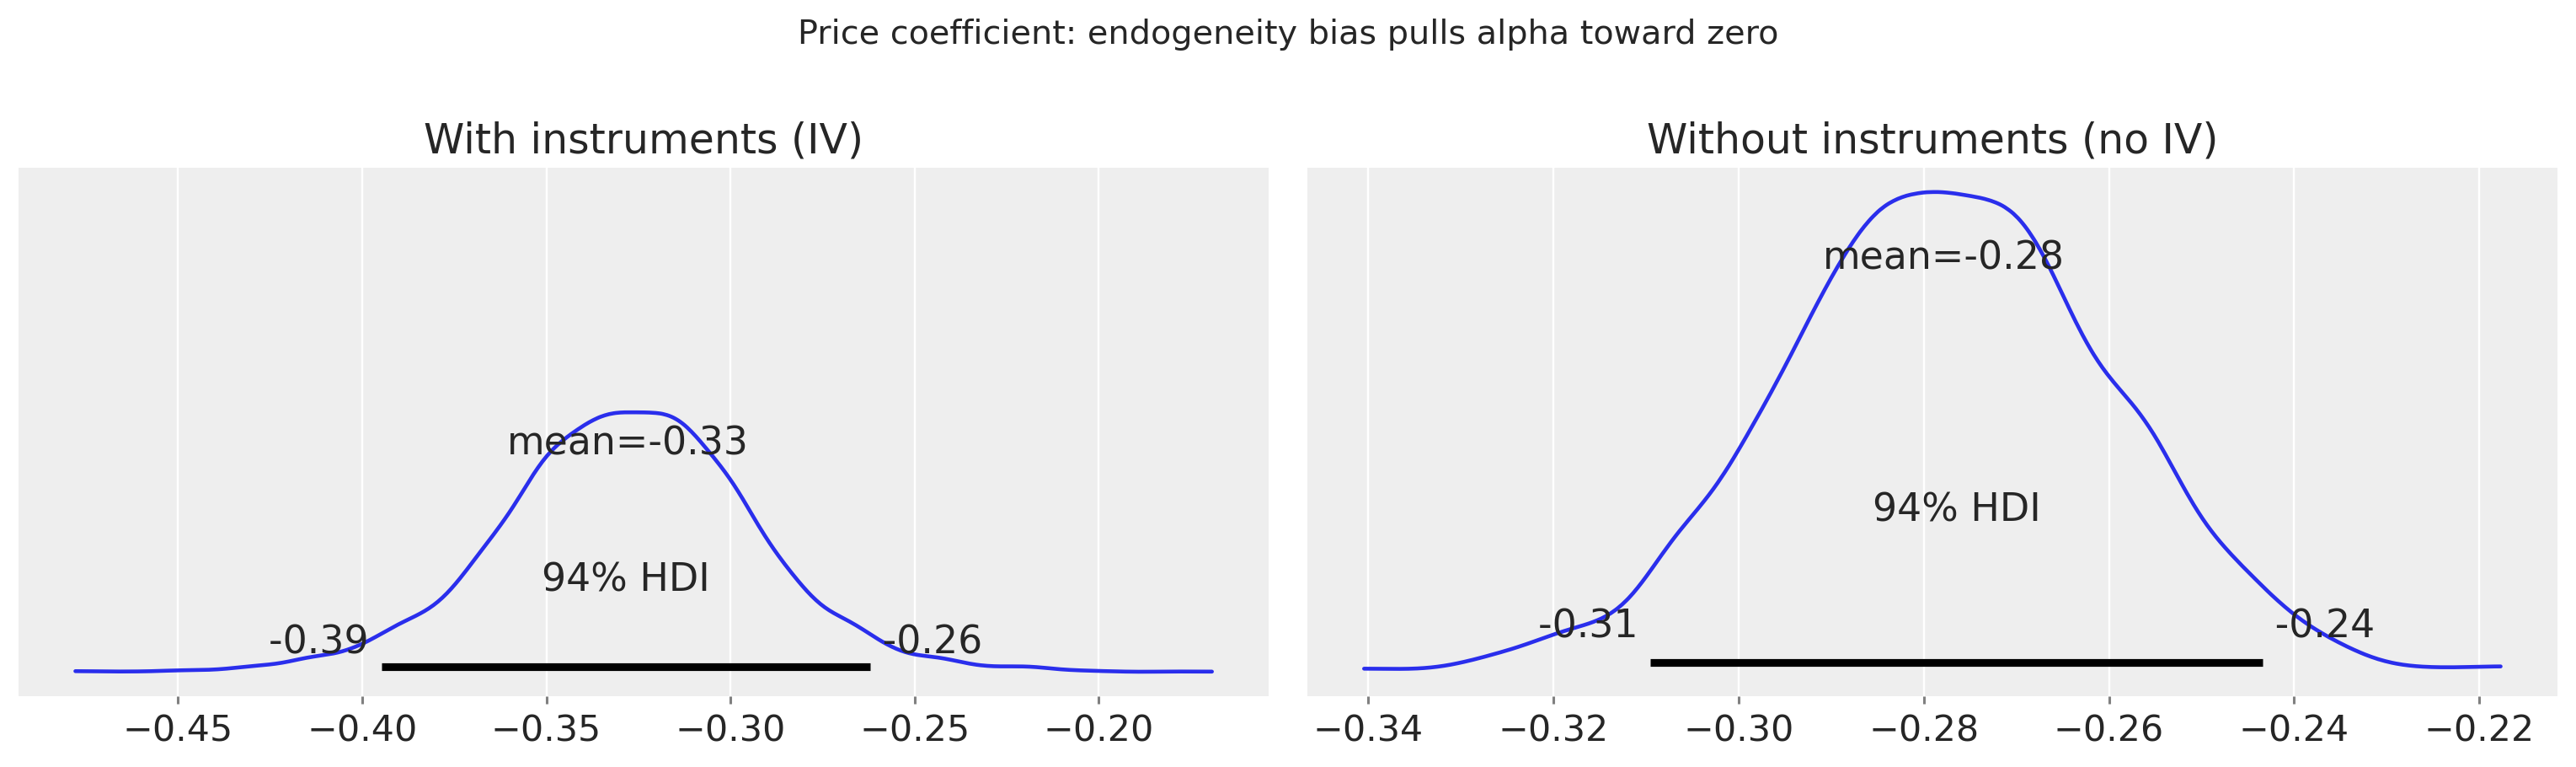

IV posterior mean:    -0.328
no-IV posterior mean: -0.278
Bias toward zero:    0.050

Without instruments the model underestimates price sensitivity,
producing unrealistically small elasticities.


In [8]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

az.plot_posterior(
    model.idata,
    var_names=["alpha_pop"],
    ax=axs[0],
)
axs[0].set_title("With instruments (IV)")

az.plot_posterior(
    model_noiv.idata,
    var_names=["alpha"],
    ax=axs[1],
)
axs[1].set_title("Without instruments (no IV)")

plt.suptitle(
    "Price coefficient: endogeneity bias pulls alpha toward zero",
    fontsize=13,
    y=1.02,
)
plt.tight_layout()
plt.show()

iv_mean = float(model.idata.posterior["alpha_pop"].mean())
noiv_mean = float(model_noiv.idata.posterior["alpha"].mean())
print(f"IV posterior mean:    {iv_mean:.3f}")
print(f"no-IV posterior mean: {noiv_mean:.3f}")
print(f"Bias toward zero:    {abs(iv_mean) - abs(noiv_mean):.3f}")
print("\nWithout instruments the model underestimates price sensitivity,")
print("producing unrealistically small elasticities.")

Note that $\alpha$ is estimated on the cents scale (price × 100). Multiply by 100 to recover the dollar-scale coefficient comparable to Nevo's $\alpha \sim -30$.


## 6. Own-price elasticities and counterfactuals

The headline test of any BLP demand estimator: do own-price elasticities land in a *plausible* range? For ready-to-eat cereal Nevo and the wider literature put the typical own-price elasticity in $[-2, -4]$.


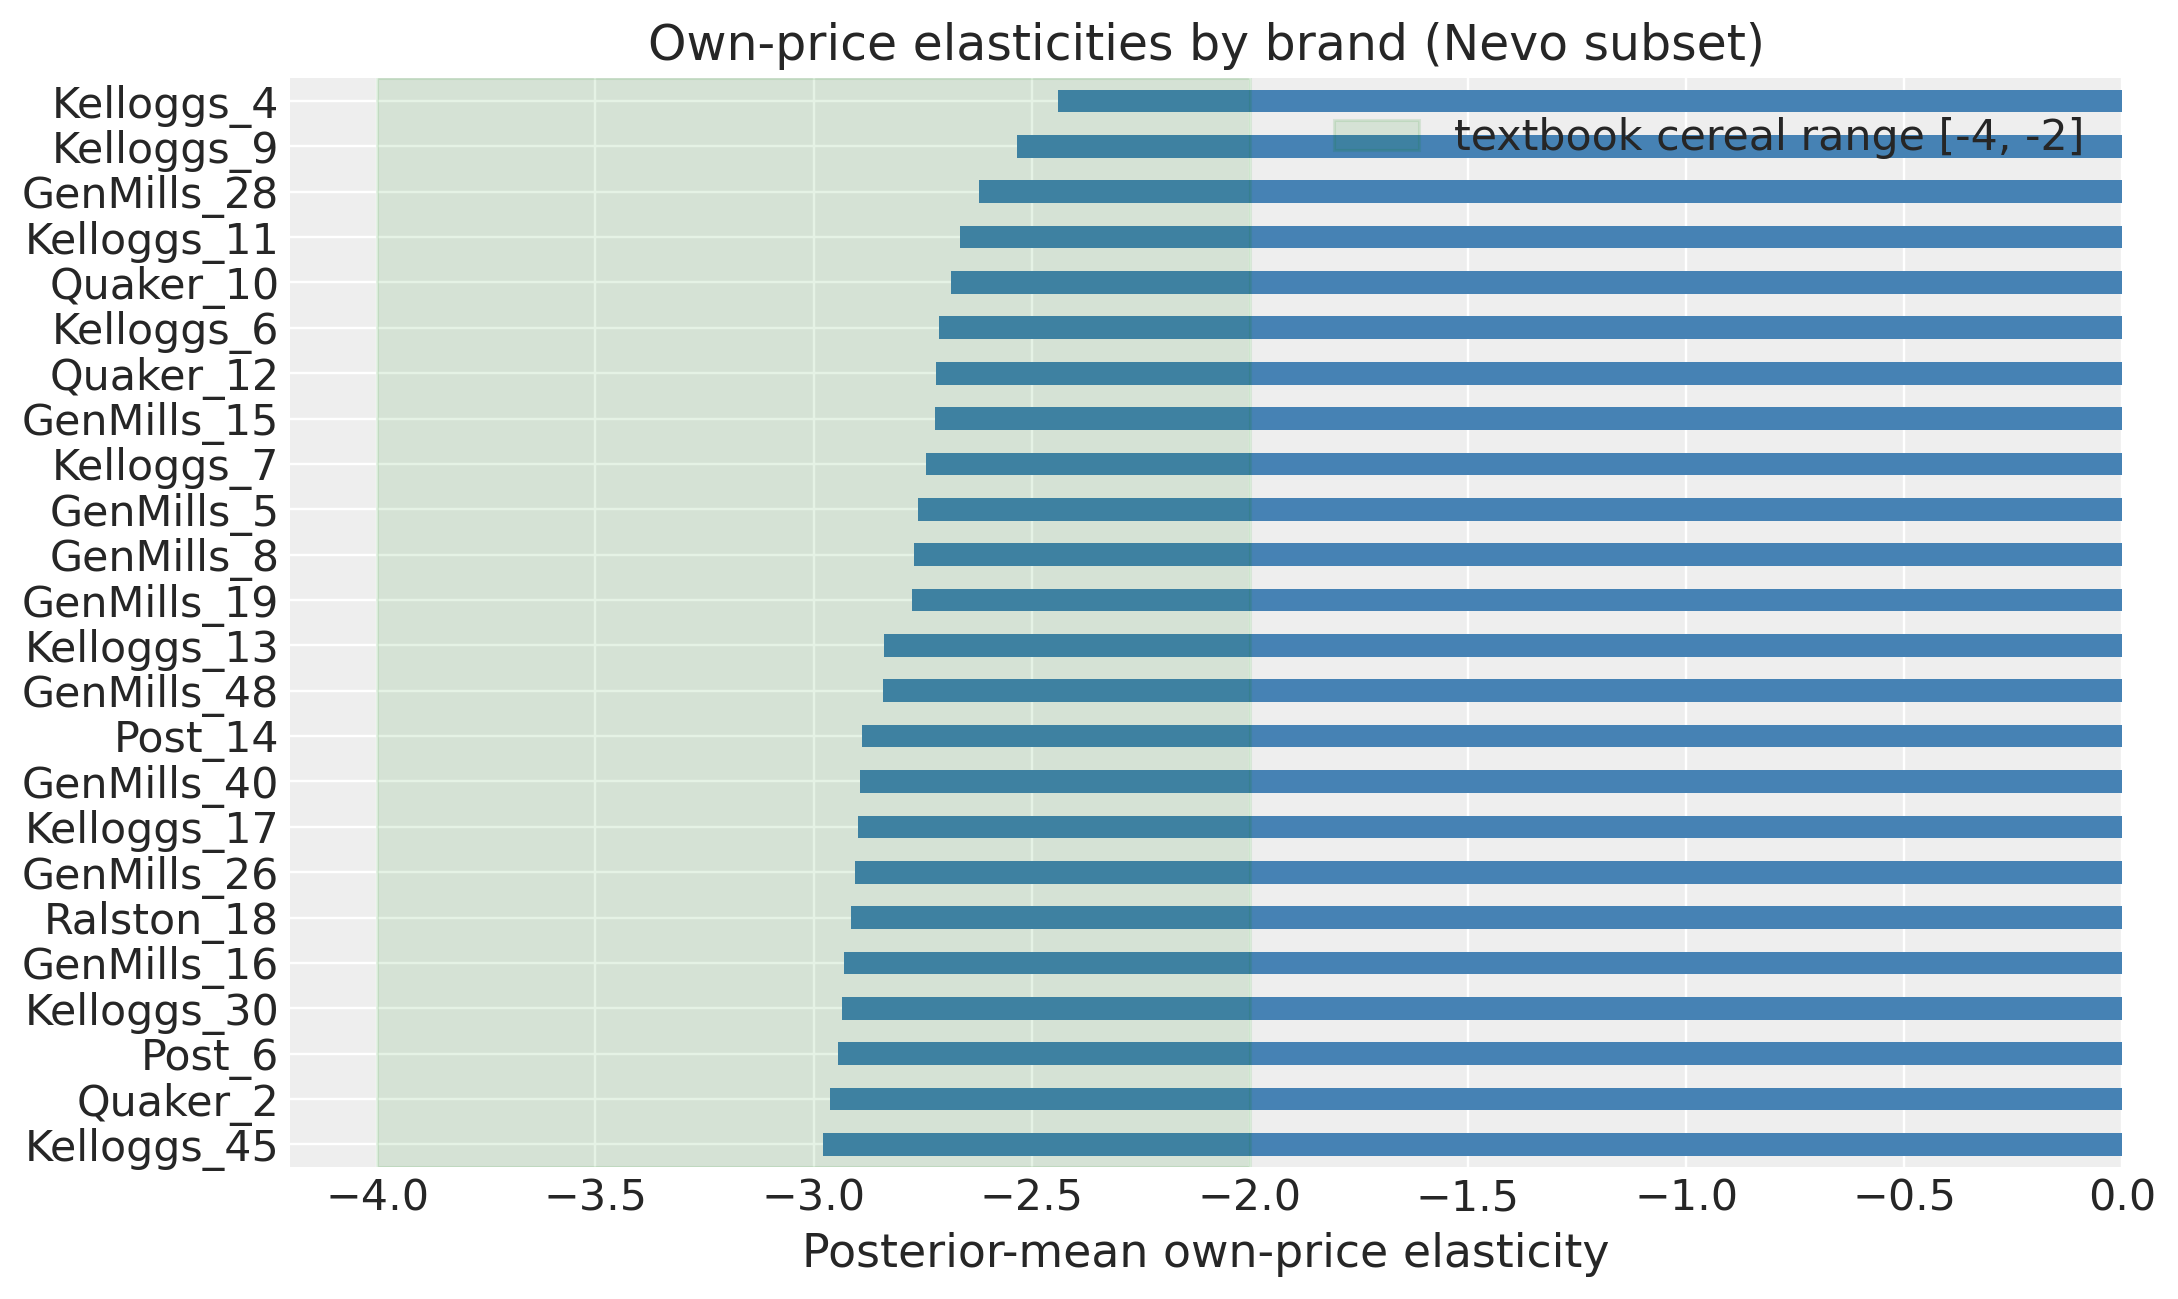

Range: [-2.979, -2.439]. Median: -2.807.


In [9]:
elast = model.elasticities(at="mean", n_samples=400)
own_eps = pd.Series(
    {
        pname: float(elast.values[:, j, j].mean())
        for j, pname in enumerate(model._inside_products)
    }
).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
own_eps.plot(kind="barh", ax=ax, color="steelblue")
ax.axvspan(-4, -2, color="green", alpha=0.1, label="textbook cereal range [-4, -2]")
ax.set_xlabel("Posterior-mean own-price elasticity")
ax.set_title("Own-price elasticities by brand (Nevo subset)")
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"Range: [{own_eps.min():.3f}, {own_eps.max():.3f}]. "
    f"Median: {own_eps.median():.3f}."
)

In [10]:
# Counterfactual: 10% price hike on the largest brand, panel-wide
target = own_eps.idxmin()  # most elastic — biggest expected response
print(f"Applying a 10% price hike to {target} (own-ε = {own_eps[target]:.2f})")

baseline = model.counterfactual_shares(price_change=None, n_samples=400)
shocked = model.counterfactual_shares(price_change={target: 0.10}, n_samples=400)

base_s = baseline["s_inside"].mean(dim="sample").values
shocked_s = shocked["s_inside"].mean(dim="sample").values
delta = shocked_s - base_s

j_target = model._inside_products.index(target)
print(f"\nMarket-average share of {target}:")
print(f"  baseline: {base_s[:, j_target].mean():.4f}")
print(f"  shocked:  {shocked_s[:, j_target].mean():.4f}")
print(f"  Δ:        {delta[:, j_target].mean():+.4f}")

# Where did the lost share go? Top rivals + outside good.
delta_outside = (
    shocked["s_outside"].mean(dim="sample") - baseline["s_outside"].mean(dim="sample")
).values.mean()
rival_changes = pd.Series(
    {
        pname: float(delta[:, j].mean())
        for j, pname in enumerate(model._inside_products)
        if pname != target
    }
).sort_values(ascending=False)

print("\nLargest gainers among rivals (top 5):")
print(rival_changes.head().to_string())
print(f"\nOutside-good Δshare: {delta_outside:+.4f}")

Applying a 10% price hike to Kelloggs_45 (own-ε = -2.98)

Market-average share of Kelloggs_45:
  baseline: 0.0102
  shocked:  0.0077
  Δ:        -0.0024

Largest gainers among rivals (top 5):
Kelloggs_6     0.000197
Kelloggs_11    0.000126
Post_14        0.000102
GenMills_8     0.000091
GenMills_19    0.000091

Outside-good Δshare: +0.0010


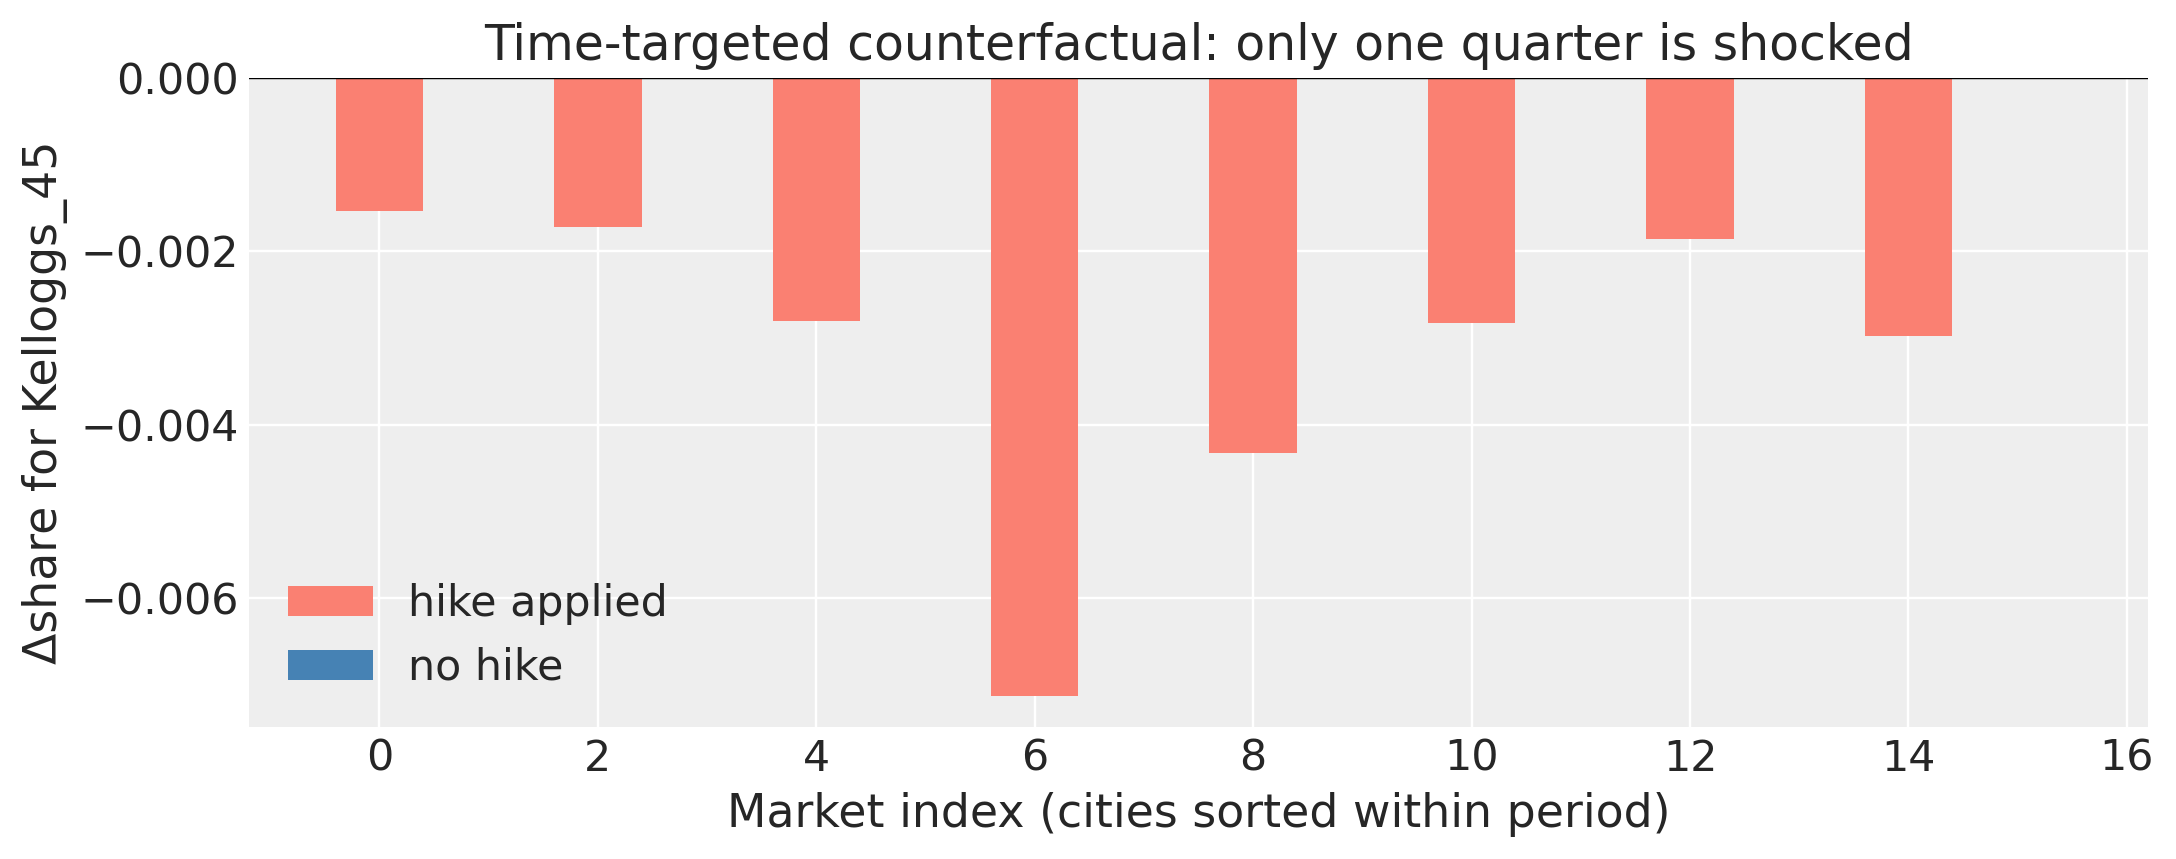


In period 353: mean Δ = -0.0031
Outside period 353: max |Δ| = 0.00e+00 (must be exactly zero — sanity check that the mask is correct)


In [11]:
# Time-targeted counterfactual: same hike, but applied only in period 1.
period_target = sorted(df["period"].unique())[0]
shocked_q = model.counterfactual_shares(
    price_change={target: 0.10}, periods=[period_target], n_samples=400
)

period_coord = shocked_q.coords["period"].values
in_window = period_coord == period_target

delta_in = (
    (shocked_q["s_inside"] - baseline["s_inside"])
    .mean(dim="sample")
    .values[:, j_target]
)

fig, ax = plt.subplots(figsize=(10, 4))
markets = np.arange(model._M)
ax.bar(markets[in_window], delta_in[in_window], color="salmon", label="hike applied")
ax.bar(markets[~in_window], delta_in[~in_window], color="steelblue", label="no hike")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("Market index (cities sorted within period)")
ax.set_ylabel(f"Δshare for {target}")
ax.set_title("Time-targeted counterfactual: only one quarter is shocked")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nIn period {period_target}: mean Δ = {delta_in[in_window].mean():+.4f}")
print(
    f"Outside period {period_target}: max |Δ| = {np.abs(delta_in[~in_window]).max():.2e} "
    "(must be exactly zero — sanity check that the mask is correct)"
)

## 7. Taste profiles across markets

The model integrates over consumer taste types to predict aggregate shares. With three random coefficients each consumer is a vector $\bm{\nu}_i = (\nu_{\text{price}}, \nu_{\text{sugar}}, \nu_{\text{mushy}})$. The stacked area chart below sorts consumers along $\nu_{\text{price}}$ only and gives a *price-marginal* view: at each x-coordinate the other two taste dimensions vary across the Halton grid. The fully multi-dimensional buyer characterisation comes from the heatmap further down (Lens 1).


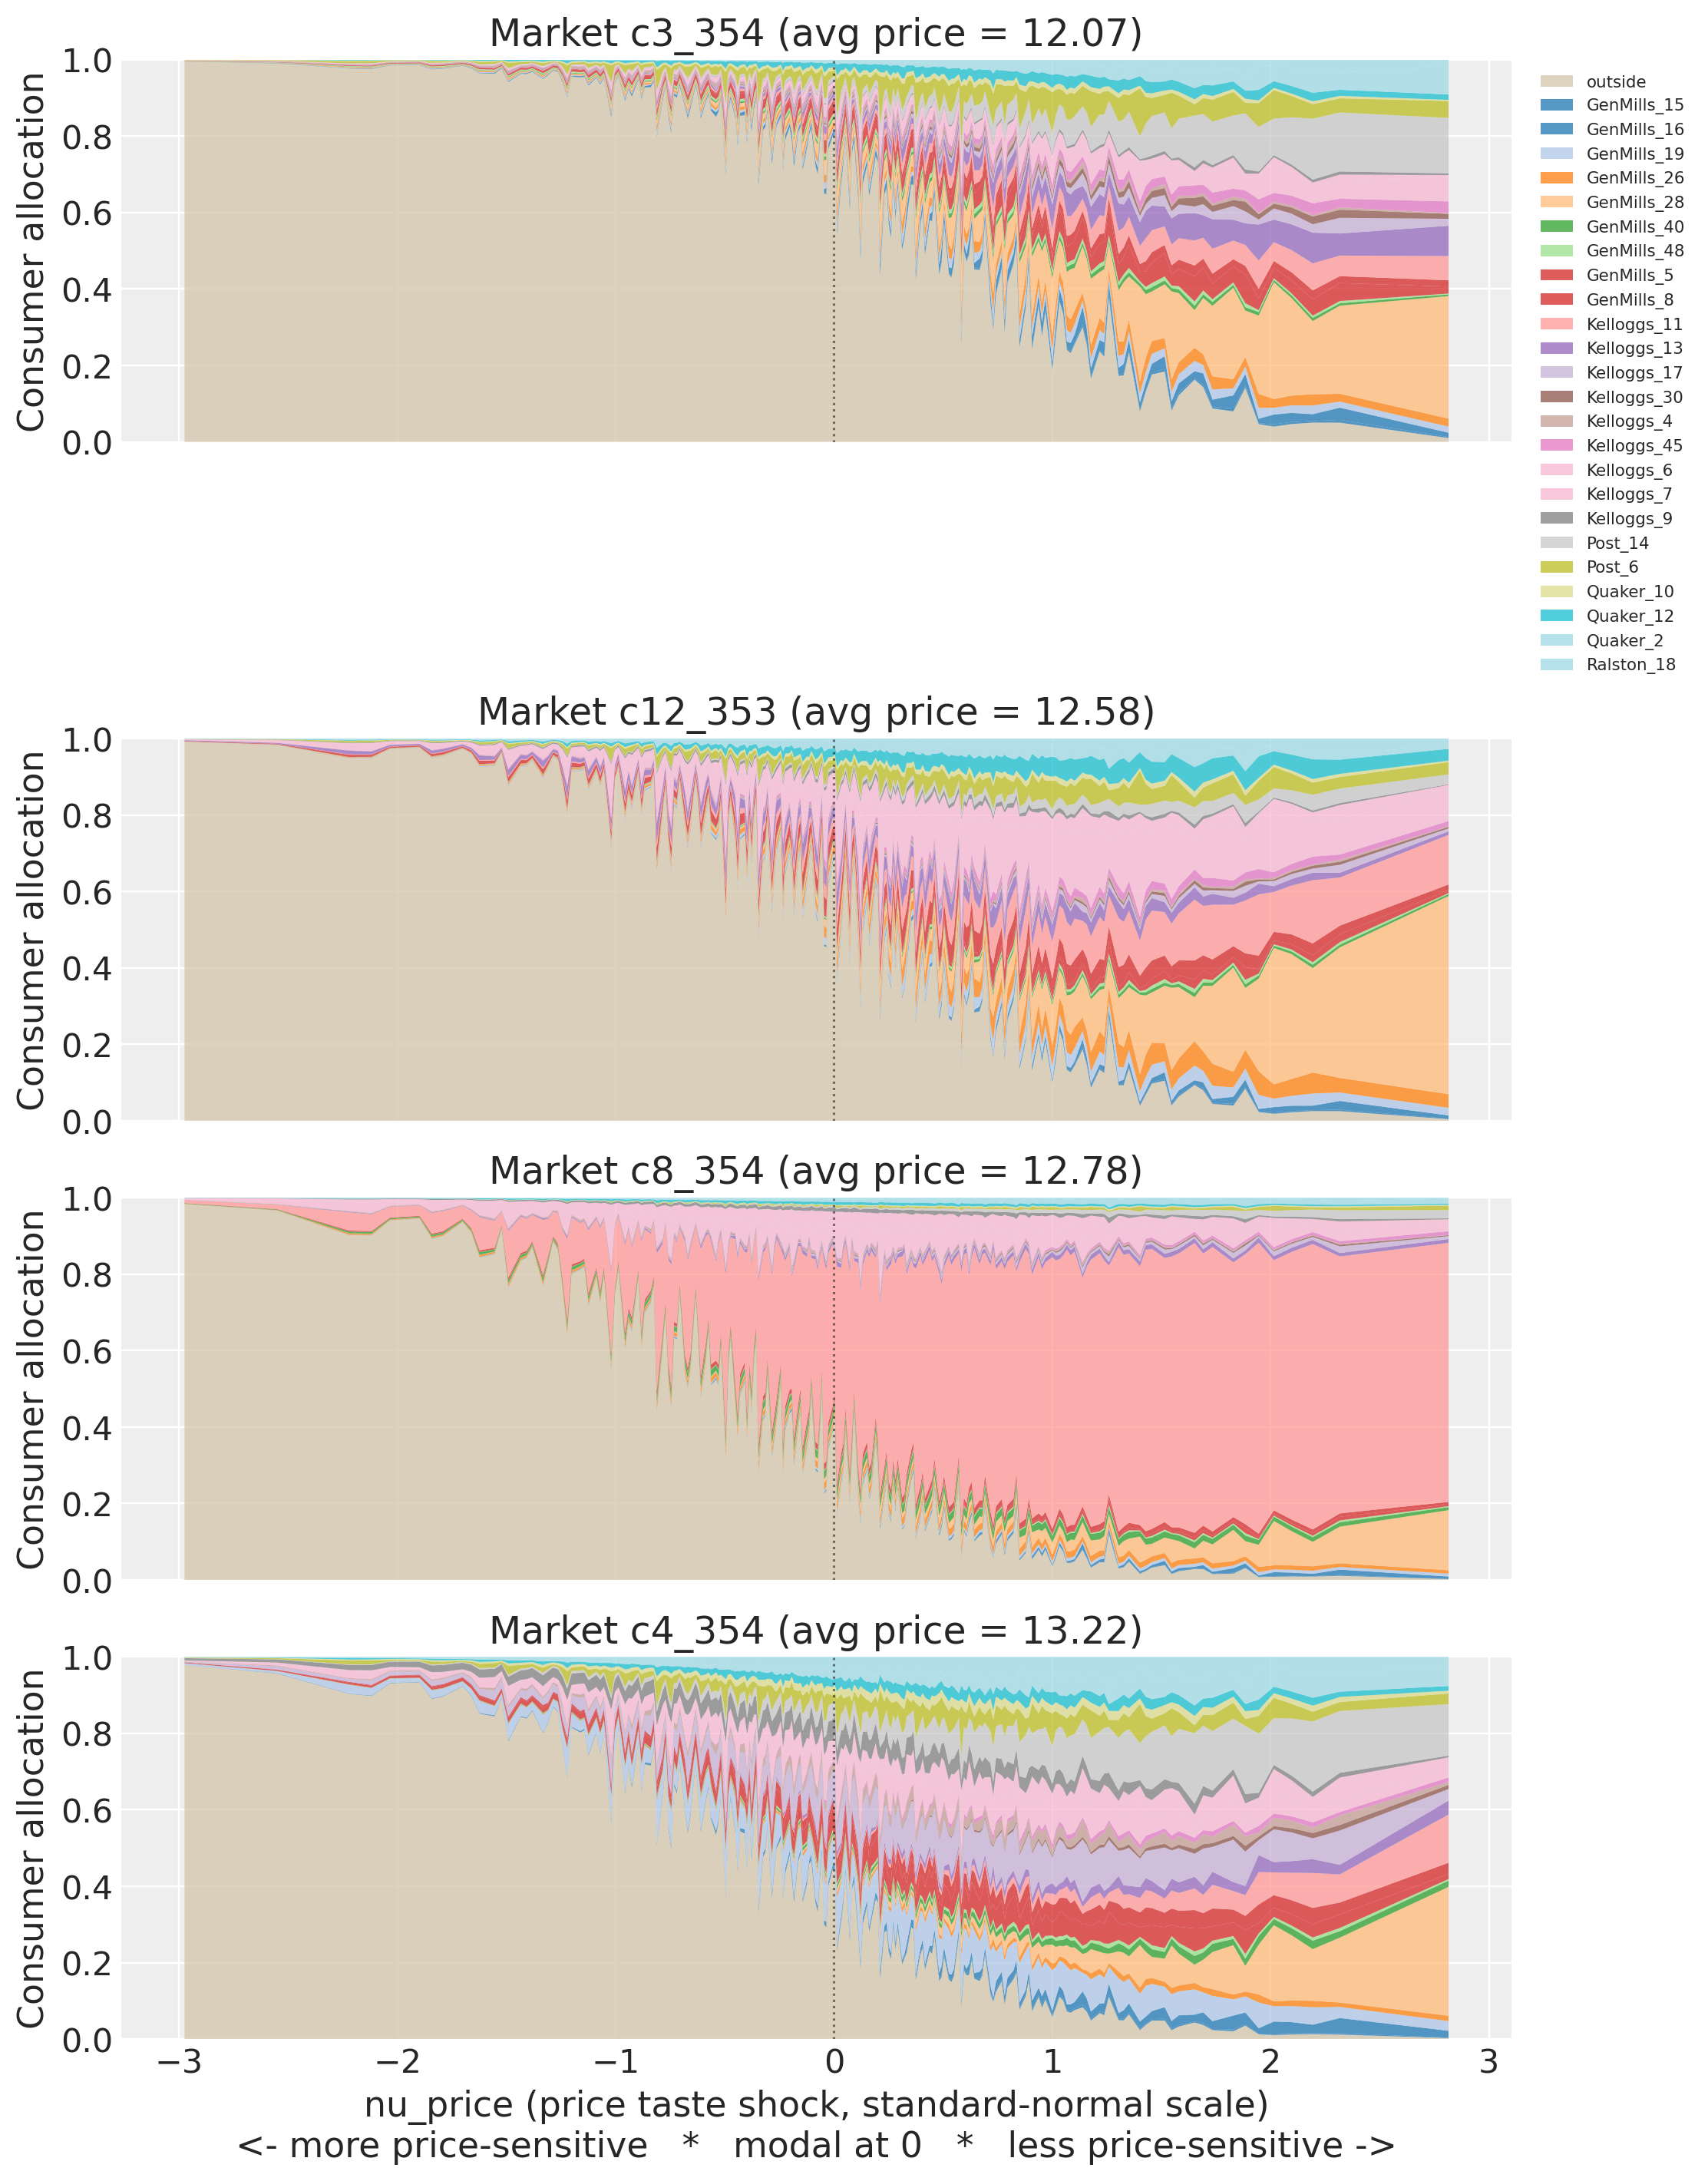

In [12]:
taste_profiles.plot_taste_profile_stacked(model, n_samples=200);

In [13]:
profiles = taste_profiles.taste_type_demand_share(model, n_samples=200)

nu_price = taste_profiles.consumer_taste_grid(model)["price"].to_numpy()
baseline = {
    "sensitive": f"{(nu_price < -1).mean():.2f}",
    "modal": f"{((nu_price >= -1) & (nu_price <= 1)).mean():.2f}",
    "insensitive": f"{(nu_price > 1).mean():.2f}",
}

print("Share of inside-good demand by taste-type bucket:\n")
print(profiles.to_string(index=False, float_format=lambda x: f"{x:6.3f}"))
print(f"\nHomogeneous baseline (flat logit): {baseline}")

Share of inside-good demand by taste-type bucket:

 market  avg_price  sensitive_pct  modal_pct  insensitive_pct
 c1_353     13.171          0.023      0.658            0.320
 c1_354     12.892          0.034      0.675            0.290
c11_353     12.588          0.033      0.670            0.297
c11_354     13.100          0.024      0.657            0.319
c12_353     12.579          0.027      0.664            0.309
c12_354     12.171          0.032      0.664            0.304
 c3_353     12.587          0.024      0.646            0.330
 c3_354     12.071          0.019      0.609            0.373
 c4_353     12.075          0.053      0.717            0.230
 c4_354     13.221          0.043      0.705            0.252
 c5_353     12.471          0.027      0.648            0.326
 c5_354     12.771          0.028      0.638            0.334
 c7_353     12.196          0.050      0.702            0.248
 c7_354     12.600          0.057      0.718            0.225
 c8_353     13.179 

### Reading the four markets

Twenty-four brands is a lot of colour. Three patterns are worth picking out:

**Cheapest market (low avg price): inside demand is diversified.** The outside good (beige) shrinks quickly as $\nu$ rises and several brands take meaningful slices. No single product dominates because at this price level the characteristic differences between brands matter more than any individual brand's unobserved-quality advantage.

**A one-brand-dominates market.** Look for the panel where, at $\nu > 0$, almost the entire stack is a single colour. This signature appears when one product has a very large posterior $\xi$ in that market (high unobserved quality given its price). The model can only explain a 40%+ inside share for one brand at moderate price by attributing it to $\xi$; consumers who can tolerate the price then almost all pick that brand. This is the model recovering a brand-level outlier from the share data alone.

**Most expensive market: outside good never disappears.** Even at $\nu \approx 2$ the outside good still holds 30–50% of the allocation. Price sensitivity remains binding at the top of the $\nu$ distribution. Compare this to the cheapest market, where the outside good is almost gone by $\nu = 0$.

The demand-share table below quantifies the same story. The flat-logit baseline (no random coefficients) would be `{sensitive: 0.16, modal: 0.68, insensitive: 0.16}`, the population weights of the three $\nu$ buckets. Wherever the observed `insensitive_pct` exceeds 0.16, the random coefficient on price is doing real work: that market's inside demand leans on consumers who can absorb the price, and a flat-logit substitution pattern would mis-predict who switches when prices change.


### Who is the average inside-good buyer?

The stacked plot is qualitative. To characterise each market by a full taste vector with posterior uncertainty, compute

$$
\bar\nu_{m,d} \;=\; E[\nu_d \mid \text{buys inside in } m]
\;=\; \frac{\sum_r \nu_{r,d} \cdot s^{\text{in}}_{m,r}}{\sum_r s^{\text{in}}_{m,r}}
$$

per posterior sample, for each dimension $d \in \{\text{price}, \text{sugar}, \text{mushy}\}$. One scalar per (sample, market, dimension) gives a posterior over "the average customer who actually buys in this market", decomposed by taste axis.


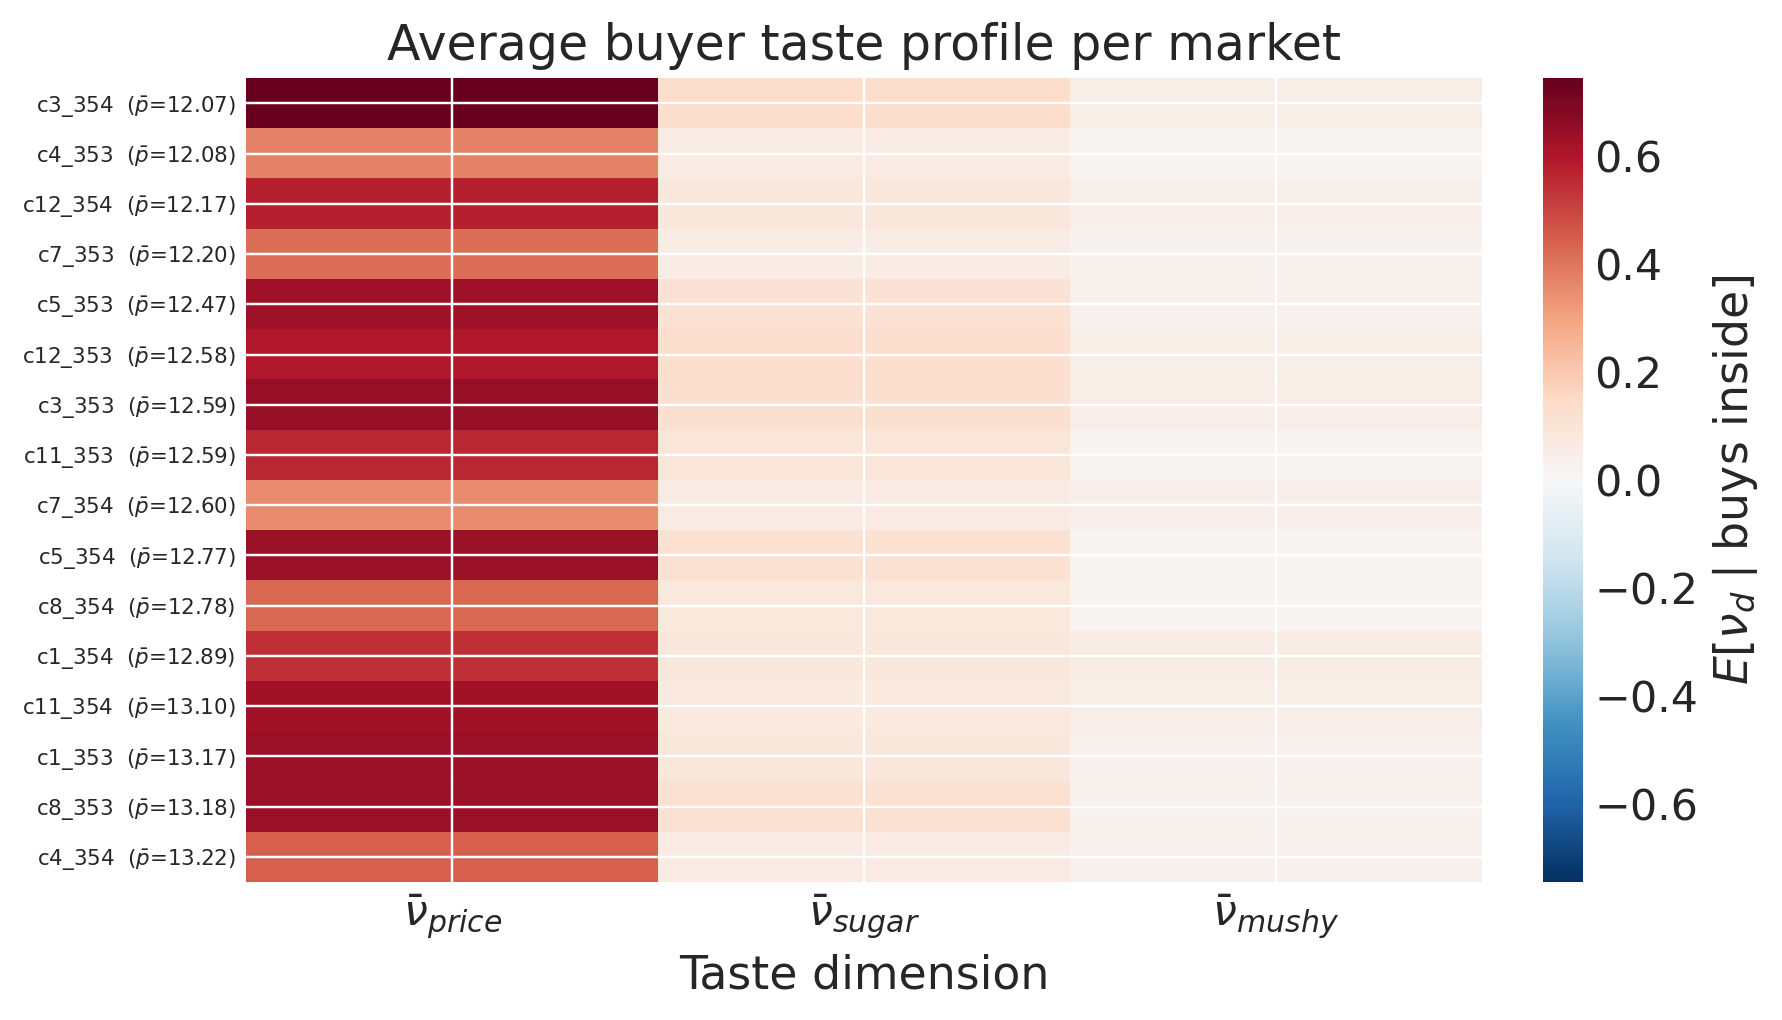

In [14]:
taste_profiles.plot_buyer_profile_heatmap(model, n_samples=300);

Each row is a market sorted by average cereal price; each column is one of the three taste dimensions. Red means the typical buyer scores *above-modal* on that dimension (price-insensitive, or strong positive preference for the characteristic). Blue means *below-modal*.

The $\bar\nu_{\text{price}}$ column should shift from blue at the top (cheap markets attract price-sensitive buyers) to red at the bottom (expensive markets keep only insensitive buyers). The $\bar\nu_{\text{sugar}}$ and $\bar\nu_{\text{mushy}}$ columns then add the characteristic story on top: a row that is red on sugar but blue on mushy is a market whose buyers prefer sugary cereals and avoid mushy ones, on top of their price-tolerance position.

The scalar "average buyer $\nu$" picture said "this market is served by price-insensitive consumers". The three-column picture says "this market is served by consumers who are price-insensitive *and* high-sugar preference *and* mushy-averse". That is the multi-dimensional taste profile the BLP machinery is designed to recover.


### Brand-level buyer profile (price dimension)

The heatmap above gives the market-level taste profile. We can also drill into individual brands: in each market, who is the typical buyer of each brand? The same construction restricted to a single product gives

$$
\bar\nu_{m,j,d} \;=\; E[\nu_d \mid \text{buys brand } j \text{ in market } m]
$$

To keep the visualisation 2D we restrict to the price dimension ($d = \text{price}$). The same construction extends to sugar and mushy by changing the slice of `model._halton`.


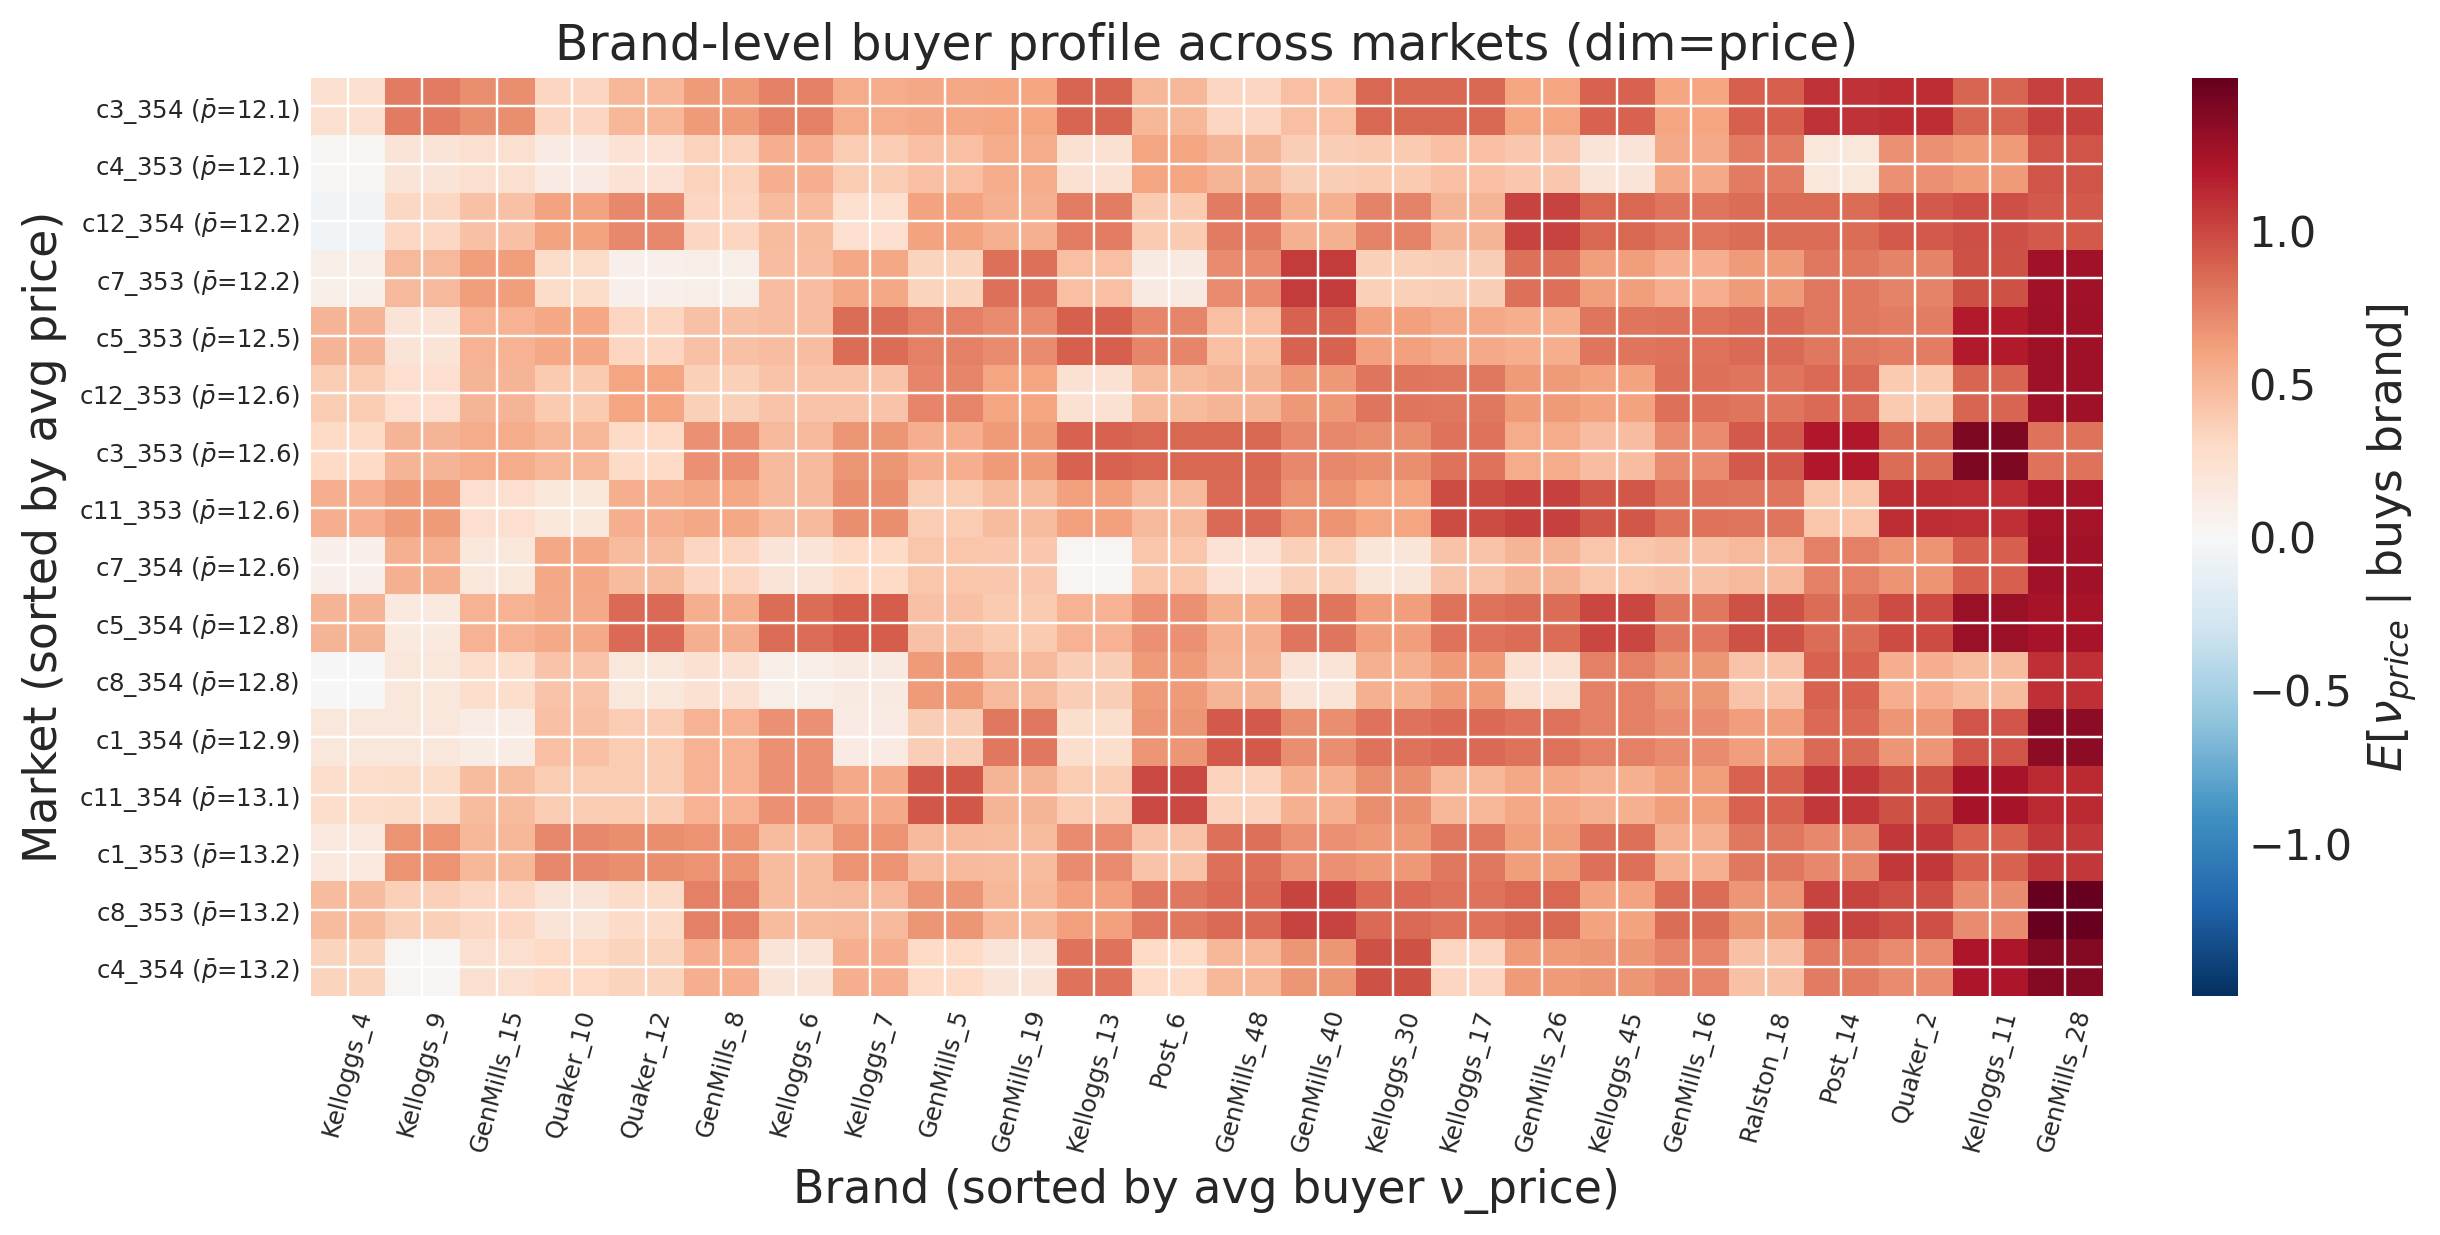

In [15]:
taste_profiles.plot_brand_buyer_heatmap(model, n_samples=200, dim=0);

Brands on the left of the heatmap (blue) serve more price-sensitive consumers; brands on the right (red) serve insensitive consumers. Two things to look for:

1. **Vertical stripes.** A brand whose column is uniformly coloured serves the same kind of customer everywhere. A brand whose column shifts colour from market to market changes its customer profile based on the local competitive context.
2. **Horizontal stripes.** A market whose row varies wildly across brands offers products that serve different consumer slices; a market whose row is flat offers a homogeneous brand mix targeting one type of buyer.

Combined with the market-level $\bar\nu_m$ from the previous lens, this gives a two-tier characterization: the average buyer in each market, and the buyer mix across brands within that market.


## 8. Caveats

- **Subset.** We fit on 8/47 cities. The full panel would deliver more statistical power, but the qualitative result (textbook elasticity range, identified $\rho$) is robust.
- **Outside-good `n_jt`.** Nevo's published data lacks per-market serving counts. The `n=1,000` placeholder enters only the heteroskedastic-Normal variance term, so it does not bias point estimates. It does compress posterior intervals slightly relative to a fit with true serving counts.
- **Demographics.** Nevo's *original* paper enriches consumer heterogeneity with demographic interactions (income, age, child presence) drawn from CPS. Our model uses the basic mixed-logit form with random coefficients on price, sugar, and mushy, but no demographic interactions.
- **Simulated data.** Nevo (2000) states the Practitioner's Guide dataset is simulated data calibrated to the cereal market. The real empirical results are in Nevo (2001, Econometrica). Results here should not be cited as findings from real market observations.


In [16]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,nutpie,pymc

Last updated: Wed Jun 10 2026

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.8.0

pymc_marketing: 0.19.4
nutpie        : 0.16.8
pymc          : 5.28.5

numpy         : 2.3.5
pymc_extras   : 0.10.0
matplotlib    : 3.10.8
pymc_marketing: 0.19.4
arviz         : 0.23.0
pandas        : 2.3.3

Watermark: 2.5.0

